In [8]:
!pip -q install pandas numpy matplotlib tqdm transformers torch rouge-score sentencepiece accelerate

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch

In [9]:
# Project root (run notebooks from the project root folder)
PROJECT_ROOT = Path.cwd()

for subdir in [
    "outputs",
    "outputs/figures",
    "outputs/tables",
    "outputs/samples",
    "outputs/models",
]:
    (PROJECT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

cleaned_path = PROJECT_ROOT / "outputs" / "tables" / "multilexsum_cleaned.parquet"

df = pd.read_parquet(cleaned_path)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Data shape:", df.shape)

display(df[[
    "split",
    "case_id",
    "case_name",
    "case_type",
    "class_action_sought",
    "cleaned_text_summary",
    "ref_long",
    "ref_short",
    "ref_tiny"
]].head(2))

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Data shape: (4539, 19)


,split,case_id,case_name,case_type,class_action_sought,cleaned_text_summary,ref_long,ref_short,ref_tiny
0,train,EE-AL-0045,"EEOC v. House of Philadelphia Center, Inc.",Equal Employment,No,IN THE UNITED STATES DISTRICT FILD COUR T P19 ...,"On September 15, 2005, the Equal Employment Op...",Equal Employment Opportunity Commission brough...,None
1,train,PB-NJ-0003,Disability Rights New Jersey v. Velez,Public Benefits / Government Services,No,"NEW JERSEY PROTECTION AND ADVOCACY, INC. BY: W...",NOTE: This is one of three identically named ...,The case was brought by a non-profit organizat...,None


In [10]:
# For summarization evaluation, prefer cases with all three reference summaries available.
eligible = df[
    (df["split"] == "train") &
    (df["cleaned_text_summary"].notna()) &
    (df["ref_long"].notna()) &
    (df["ref_short"].notna()) &
    (df["ref_tiny"].notna())
].copy()

# Remove empty reference strings if any.
eligible = eligible[
    eligible["ref_long"].astype(str).str.strip().ne("") &
    eligible["ref_short"].astype(str).str.strip().ne("") &
    eligible["ref_tiny"].astype(str).str.strip().ne("")
].copy()

print("Eligible train cases with all 3 summaries:", eligible.shape[0])

# Choose a small but varied sample across case types.
# We also avoid extremely huge cases for this first demo run.
eligible["summary_word_count"] = eligible["cleaned_text_summary"].astype(str).str.split().apply(len)

sample_pool = eligible[
    (eligible["summary_word_count"] >= 1000) &
    (eligible["summary_word_count"] <= 40000)
].copy()

sample_cases = (
    sample_pool
    .sort_values(["case_type", "summary_word_count"])
    .groupby("case_type", group_keys=False)
    .head(1)
    .sample(n=5, random_state=42)
    .copy()
)

sample_cases = sample_cases.reset_index(drop=True)

display(sample_cases[[
    "case_id",
    "case_name",
    "case_type",
    "class_action_sought",
    "summary_word_count",
    "ref_long",
    "ref_short",
    "ref_tiny"
]])

print("Selected case types:")
display(sample_cases["case_type"].value_counts())


Eligible train cases with all 3 summaries: 1129


,case_id,case_name,case_type,class_action_sought,summary_word_count,ref_long,ref_short,ref_tiny
0,PN-MN-0006,Williams v. Minneapolis,Policing,Yes,2608,This class-action lawsuit was brought on June ...,This class-action alleged that the Minneapolis...,This case against @MinneapolisPD alleges that ...
1,PD-TX-0003,Stone v. Tom Green County,Indigent Defense,No,4447,"On October 1, 2019, a criminal defense lawyer ...","In October 2019, a criminal defense attorney s...",Criminal defense lawyers sues District Attorne...
2,CW-IL-0006,Aristotle P. v. McDonald,Child Welfare,Yes,27823,"The plaintiffs, children who had been made war...","Plaintiffs, a class of children in the custody...",Children in the custody of state of IL granted...
3,IM-DC-0048,Buzzfeed Inc. v. U.S. Immigration and Customs ...,Immigration and/or the Border,No,3034,"On June 25, 2018, Buzzfeed and Loevy & Loevy b...","On June 26, 2018, Buzzfeed and Loevy & Loevy s...",Buzzfeed sued Immigration and Customs Enforcem...
4,PC-MO-0012,Qandah v. Lombardi,Prison Conditions,Yes,5175,"On August 8, 2012, two Missouri prisoners file...",Missouri prisoners filed a class-action lawsui...,Judge finds prisoners' challenge of Amendment ...


Selected case types:


,count
case_type,
Policing,1
Indigent Defense,1
Child Welfare,1
Immigration and/or the Border,1
Prison Conditions,1


In [11]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "sshleifer/distilbart-cnn-12-6"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

model = model.to(device)
model.eval()

print("Loaded model:", MODEL_NAME)
print("Device:", device)

# Quick tokenizer/model sanity check
test_text = (
    "The plaintiff filed a civil rights lawsuit alleging discrimination. "
    "The court considered the claims and later approved a settlement."
)

inputs = tokenizer(
    test_text,
    return_tensors="pt",
    truncation=True,
    max_length=512
).to(device)

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=40,
        min_length=10,
        num_beams=2,
        do_sample=False
    )

test_summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("Test summary:")
print(test_summary)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loaded model: sshleifer/distilbart-cnn-12-6
Device: cuda
Test summary:
 The plaintiff filed a civil rights lawsuit alleging discrimination . The court considered the claims and later approved a settlement .


In [14]:
def chunk_text_by_tokens(text, tokenizer, chunk_size=768, overlap=80):
    """
    Split long text into overlapping token chunks.

    DistilBART cannot process very long legal cases directly, so we summarize
    smaller chunks first and then summarize the combined chunk summaries.
    """
    if pd.isna(text) or text is None or str(text).strip() == "":
        return []

    # truncation=False avoids warnings because we are intentionally tokenizing
    # long documents before manually chunking them.
    token_ids = tokenizer.encode(
        str(text),
        add_special_tokens=False,
        truncation=False
    )

    chunks = []
    start = 0

    while start < len(token_ids):
        end = min(start + chunk_size, len(token_ids))
        chunk_ids = token_ids[start:end]
        chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True)
        chunks.append(chunk_text)

        if end == len(token_ids):
            break

        start = end - overlap

    return chunks


def summarize_text_once(text, max_new_tokens=120, min_length=30, num_beams=2):
    """
    Summarize one text segment that fits within the model context window.
    """
    if pd.isna(text) or text is None or str(text).strip() == "":
        return ""

    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_length=min_length,
            num_beams=num_beams,
            do_sample=False,
            early_stopping=True
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


def make_tiny_summary(text, max_words=35):
    """
    Convert generated text into a compact tiny summary.

    This avoids naive sentence splitting on periods because legal text often
    contains abbreviations such as U.S., U.N., D.C., Inc., etc.
    """
    if pd.isna(text) or text is None or str(text).strip() == "":
        return ""

    text = str(text).replace("\n", " ").strip()
    text = re.sub(r"\s+", " ", text)

    words = text.split()

    # Keep as-is if already short.
    if len(words) <= max_words:
        return text if text.endswith(".") else text + "."

    # Otherwise truncate by words instead of splitting on periods.
    tiny = " ".join(words[:max_words]).strip()
    return tiny if tiny.endswith(".") else tiny + "."


def hierarchical_summarize(
    text,
    level="short",
    chunk_size=768,
    overlap=80,
    max_chunks=8
):
    """
    Hierarchical summarization:
    1. Split long legal text into chunks.
    2. Summarize each chunk.
    3. Combine chunk summaries.
    4. Summarize again into long/short/tiny form.

    max_chunks is used for runtime control in this demo notebook.
    """
    chunks = chunk_text_by_tokens(
        text,
        tokenizer,
        chunk_size=chunk_size,
        overlap=overlap
    )

    if len(chunks) == 0:
        return ""

    # Runtime control: use the first max_chunks chunks for this demo.
    # This keeps the notebook reproducible and prevents very long cases from
    # running forever.
    chunks = chunks[:max_chunks]

    chunk_summaries = []

    for chunk in chunks:
        chunk_summary = summarize_text_once(
            chunk,
            max_new_tokens=120,
            min_length=30,
            num_beams=2
        )
        chunk_summaries.append(chunk_summary)

    combined_summary = " ".join(chunk_summaries)

    if level == "long":
        return summarize_text_once(
            combined_summary,
            max_new_tokens=260,
            min_length=100,
            num_beams=2
        )

    if level == "short":
        return summarize_text_once(
            combined_summary,
            max_new_tokens=140,
            min_length=50,
            num_beams=2
        )

    if level == "tiny":
        tiny_raw = summarize_text_once(
            combined_summary,
            max_new_tokens=60,
            min_length=15,
            num_beams=2
        )
        return make_tiny_summary(tiny_raw, max_words=35)

    raise ValueError("level must be one of: long, short, tiny")


# Quick chunking test
sample_text = sample_cases.loc[0, "cleaned_text_summary"]
sample_chunks = chunk_text_by_tokens(
    sample_text,
    tokenizer,
    chunk_size=768,
    overlap=80
)

print("Sample case:", sample_cases.loc[0, "case_id"])
print("Total chunks:", len(sample_chunks))
print("Using chunks in demo:", min(len(sample_chunks), 8))
print("First chunk preview:")
print(sample_chunks[0][:500])


Sample case: PN-MN-0006
Total chunks: 6
Using chunks in demo: 6
First chunk preview:
UNITED STATES DISTRICT COURT DISTRICT OF MINNESOTA Annette Williams and all others similarly situated, Plaintiffs vs. The City of Minneapolis, Officers John Doe 1-100 Defendants Case No: 0:20-cv-1303 CLASS ACTION COMPLAINT Plaintiff Annette Williams (hereinafter “Plaintiff”), by and through her attorneys, for her Complaint against Defendants and on behalf of all others similarly situated, upon personal knowledge as to her own facts and conduct and on information and belief as to all other matter


In [16]:
import re

generated_rows = []

for _, row in tqdm(sample_cases.iterrows(), total=len(sample_cases)):
    case_id = row["case_id"]
    case_text = row["cleaned_text_summary"]

    print(f"\nSummarizing case: {case_id} | {row['case_type']}")

    gen_long = hierarchical_summarize(
        case_text,
        level="long",
        chunk_size=768,
        overlap=80,
        max_chunks=8
    )

    gen_short = hierarchical_summarize(
        case_text,
        level="short",
        chunk_size=768,
        overlap=80,
        max_chunks=8
    )

    gen_tiny = hierarchical_summarize(
        case_text,
        level="tiny",
        chunk_size=768,
        overlap=80,
        max_chunks=8
    )

    generated_rows.append({
        "case_id": case_id,
        "case_name": row["case_name"],
        "case_type": row["case_type"],
        "class_action_sought": row["class_action_sought"],
        "source_word_count": len(str(case_text).split()),
        "generated_long": gen_long,
        "generated_short": gen_short,
        "generated_tiny": gen_tiny,
        "ref_long": row["ref_long"],
        "ref_short": row["ref_short"],
        "ref_tiny": row["ref_tiny"],
    })

generated_df = pd.DataFrame(generated_rows)

display(generated_df[[
    "case_id",
    "case_type",
    "source_word_count",
    "generated_long",
    "generated_short",
    "generated_tiny"
]])

generated_df.to_csv(
    PROJECT_ROOT / "outputs" / "samples" / "sample_summaries.csv",
    index=False
)

print("Saved generated summaries to outputs/samples/sample_summaries.csv")


  0%|          | 0/5 [00:00<?, ?it/s]


Summarizing case: PN-MN-0006 | Policing

Summarizing case: PD-TX-0003 | Indigent Defense

Summarizing case: CW-IL-0006 | Child Welfare

Summarizing case: IM-DC-0048 | Immigration and/or the Border 

Summarizing case: PC-MO-0012 | Prison Conditions


,case_id,case_type,source_word_count,generated_long,generated_short,generated_tiny
0,PN-MN-0006,Policing,2608,Minneapolis Police Department officer Derek Ch...,Minneapolis Police Department officer Derek Ch...,Minneapolis Police Department officer Derek Ch...
1,PD-TX-0003,Indigent Defense,4447,Patricia Stone argued in a criminal appeal tha...,Patricia Stone argued in a criminal appeal tha...,Patricia Stone argued in a criminal appeal tha...
2,CW-IL-0006,Child Welfare,27823,Class action lawsuit in which consent order wa...,Class action lawsuit in which consent order wa...,Class action lawsuit in which consent order wa...
3,IM-DC-0048,Immigration and/or the Border,3034,U.N. Immigrations & Customs Enforcement is acc...,U.N. Immigrations & Customs Enforcement is acc...,U.N. Immigrations & Customs Enforcement is acc...
4,PC-MO-0012,Prison Conditions,5175,Amendment 2 would ensure that any person has t...,Amendment 2 would ensure that any person has t...,Amendment 2 would ensure that any person has t...


Saved generated summaries to outputs/samples/sample_summaries.csv


In [17]:
def count_words(text):
    if pd.isna(text) or text is None:
        return 0
    return len(str(text).split())

for col in [
    "generated_long",
    "generated_short",
    "generated_tiny",
    "ref_long",
    "ref_short",
    "ref_tiny",
]:
    generated_df[f"{col}_word_count"] = generated_df[col].apply(count_words)

length_cols = [
    "case_id",
    "case_type",
    "generated_long_word_count",
    "generated_short_word_count",
    "generated_tiny_word_count",
    "ref_long_word_count",
    "ref_short_word_count",
    "ref_tiny_word_count",
]

display(generated_df[length_cols])

length_summary = generated_df[[
    "generated_long_word_count",
    "generated_short_word_count",
    "generated_tiny_word_count",
    "ref_long_word_count",
    "ref_short_word_count",
    "ref_tiny_word_count",
]].describe().T

display(length_summary)

# Save length comparison
generated_df[length_cols].to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "summarization_length_comparison.csv",
    index=False
)

print("Saved length comparison table.")


,case_id,case_type,generated_long_word_count,generated_short_word_count,generated_tiny_word_count,ref_long_word_count,ref_short_word_count,ref_tiny_word_count
0,PN-MN-0006,Policing,104,62,35,196,123,33
1,PD-TX-0003,Indigent Defense,101,58,35,212,54,17
2,CW-IL-0006,Child Welfare,91,78,35,871,100,19
3,IM-DC-0048,Immigration and/or the Border,90,56,34,641,87,18
4,PC-MO-0012,Prison Conditions,105,88,35,397,64,17


,count,mean,std,min,25%,50%,75%,max
generated_long_word_count,5.0,98.2,7.190271,90.0,91.0,101.0,104.0,105.0
generated_short_word_count,5.0,68.4,13.957077,56.0,58.0,62.0,78.0,88.0
generated_tiny_word_count,5.0,34.8,0.447214,34.0,35.0,35.0,35.0,35.0
ref_long_word_count,5.0,463.4,290.169433,196.0,212.0,397.0,641.0,871.0
ref_short_word_count,5.0,85.6,27.718225,54.0,64.0,87.0,100.0,123.0
ref_tiny_word_count,5.0,20.8,6.870226,17.0,17.0,18.0,19.0,33.0


Saved length comparison table.


### Length comparison finding

The generated summaries follow the intended ordering: long summaries are longer than short summaries, and short summaries are longer than tiny summaries. However, the generated long summaries are much shorter than the expert-written long references. This is expected because the demo uses a lightweight DistilBART model and only the first few chunks of each long legal case for runtime control.

The generated short summaries are closer in length to the reference short summaries. The tiny summaries are consistently compact, although they are slightly longer than most reference tiny summaries because they are capped by words rather than forced into a very short one-sentence format.

In [18]:
comparison_cols = [
    "case_id",
    "case_type",
    "generated_short",
    "ref_short",
    "generated_tiny",
    "ref_tiny",
]

qualitative_comparison = generated_df[comparison_cols].copy()

display(qualitative_comparison)

qualitative_comparison.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "summarization_qualitative_comparison.csv",
    index=False
)

# Print a readable case-by-case view
for _, row in qualitative_comparison.iterrows():
    print("=" * 100)
    print(f"Case ID: {row['case_id']} | Case Type: {row['case_type']}")
    print("\nGenerated short:")
    print(row["generated_short"])
    print("\nReference short:")
    print(row["ref_short"])
    print("\nGenerated tiny:")
    print(row["generated_tiny"])
    print("\nReference tiny:")
    print(row["ref_tiny"])
    print()


,case_id,case_type,generated_short,ref_short,generated_tiny,ref_tiny
0,PN-MN-0006,Policing,Minneapolis Police Department officer Derek Ch...,This class-action alleged that the Minneapolis...,Minneapolis Police Department officer Derek Ch...,This case against @MinneapolisPD alleges that ...
1,PD-TX-0003,Indigent Defense,Patricia Stone argued in a criminal appeal tha...,"In October 2019, a criminal defense attorney s...",Patricia Stone argued in a criminal appeal tha...,Criminal defense lawyers sues District Attorne...
2,CW-IL-0006,Child Welfare,Class action lawsuit in which consent order wa...,"Plaintiffs, a class of children in the custody...",Class action lawsuit in which consent order wa...,Children in the custody of state of IL granted...
3,IM-DC-0048,Immigration and/or the Border,U.N. Immigrations & Customs Enforcement is acc...,"On June 26, 2018, Buzzfeed and Loevy & Loevy s...",U.N. Immigrations & Customs Enforcement is acc...,Buzzfeed sued Immigration and Customs Enforcem...
4,PC-MO-0012,Prison Conditions,Amendment 2 would ensure that any person has t...,Missouri prisoners filed a class-action lawsui...,Amendment 2 would ensure that any person has t...,Judge finds prisoners' challenge of Amendment ...


Case ID: PN-MN-0006 | Case Type: Policing

Generated short:
Minneapolis Police Department officer Derek Chauvin killed an unarmed and restrained black man, George Floyd, by kneeling on the man’s neck for nearly nine minutes . Video of the incident was distributed worldwide via social media, resulting in mass protests across the country . Plaintiff Annette Williams has since suffered from labored breathing and chest pain interfering with her daily activities .

Reference short:
This class-action alleged that the Minneapolis police used tactics on peaceful protesters that were in violation of the First and Fourteenth Amendments. The case arose out of the nationwide protests following the police killing of George Floyd. The plaintiff in this case alleged that a police officer (John Doe 1) used pepper spray on her and her daughter while they were peacefully protesting on the sidewalk. The plaintiff sued under 42 U.S.C. Section 1983, claiming that the police violated her right to free speec

### Qualitative summarization finding

The generated summaries are generally useful, but they are not always fully aligned with the expert-written references. For several cases, the model captures the broad topic correctly, such as indigent defense retaliation, child welfare visitation rights, and prisoners’ religious liberty.

However, the model sometimes over-focuses on early source-document context or produces factual wording errors. For example, in the policing case, the generated summary focuses heavily on George Floyd and Derek Chauvin, while the reference summary focuses on police force used against peaceful protesters. In the immigration/FOIA case, the generated summary incorrectly phrases ICE as if it were the plaintiff.

This shows why automatic summarization for legal documents requires careful evaluation. The model is useful for a quick draft, but the output should not be treated as a verified legal summary without human review.

ROUGE scores by case and summary level:


,case_id,case_type,summary_level,rouge1_f,rouge2_f,rougeL_f
0,PN-MN-0006,Policing,long,0.263158,0.039735,0.138158
1,PN-MN-0006,Policing,short,0.204301,0.043478,0.118280
2,PN-MN-0006,Policing,tiny,0.205882,0.060606,0.147059
3,PD-TX-0003,Indigent Defense,long,0.400000,0.204473,0.247619
4,PD-TX-0003,Indigent Defense,short,0.333333,0.107143,0.280702
5,PD-TX-0003,Indigent Defense,tiny,0.222222,0.038462,0.185185
6,CW-IL-0006,Child Welfare,long,0.154786,0.087755,0.077393
7,CW-IL-0006,Child Welfare,short,0.431818,0.149425,0.261364
8,CW-IL-0006,Child Welfare,tiny,0.264151,0.000000,0.226415
9,IM-DC-0048,Immigration and/or the Border,long,0.193809,0.091768,0.121131


Average ROUGE by summary level:


,rouge1_f,rouge2_f,rougeL_f
summary_level,,,
long,0.2472,0.0966,0.1421
short,0.3302,0.0792,0.1922
tiny,0.2146,0.0517,0.1727


<Figure size 700x400 with 0 Axes>

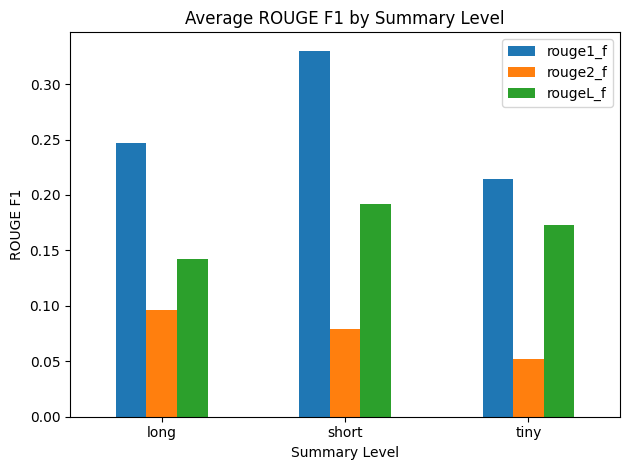

In [19]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

def compute_rouge_row(generated, reference):
    if pd.isna(generated) or pd.isna(reference):
        return {
            "rouge1_f": np.nan,
            "rouge2_f": np.nan,
            "rougeL_f": np.nan,
        }

    generated = str(generated).strip()
    reference = str(reference).strip()

    if generated == "" or reference == "":
        return {
            "rouge1_f": np.nan,
            "rouge2_f": np.nan,
            "rougeL_f": np.nan,
        }

    scores = scorer.score(reference, generated)

    return {
        "rouge1_f": scores["rouge1"].fmeasure,
        "rouge2_f": scores["rouge2"].fmeasure,
        "rougeL_f": scores["rougeL"].fmeasure,
    }


rouge_rows = []

summary_pairs = [
    ("long", "generated_long", "ref_long"),
    ("short", "generated_short", "ref_short"),
    ("tiny", "generated_tiny", "ref_tiny"),
]

for _, row in generated_df.iterrows():
    for level, gen_col, ref_col in summary_pairs:
        rouge_scores = compute_rouge_row(row[gen_col], row[ref_col])

        rouge_rows.append({
            "case_id": row["case_id"],
            "case_type": row["case_type"],
            "summary_level": level,
            **rouge_scores
        })

rouge_df = pd.DataFrame(rouge_rows)

print("ROUGE scores by case and summary level:")
display(rouge_df)

print("Average ROUGE by summary level:")
rouge_summary = (
    rouge_df
    .groupby("summary_level")[["rouge1_f", "rouge2_f", "rougeL_f"]]
    .mean()
    .round(4)
)

display(rouge_summary)

rouge_df.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "summarization_rouge_by_case.csv",
    index=False
)

rouge_summary.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "summarization_rouge_summary.csv"
)

plt.figure(figsize=(7, 4))
rouge_summary.plot(kind="bar")
plt.title("Average ROUGE F1 by Summary Level")
plt.xlabel("Summary Level")
plt.ylabel("ROUGE F1")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "rouge_by_summary_level.png", dpi=150)
plt.show()

### ROUGE evaluation finding

ROUGE scores are moderate, which is expected for abstractive summarization of long legal documents. The short summaries achieve the strongest average ROUGE-1 and ROUGE-L scores, likely because the generated summaries are closest in length and level of detail to the expert short references.

The generated long summaries underperform against long references because the model uses only a limited number of chunks for runtime control and produces shorter outputs than the expert long summaries. Tiny-summary ROUGE is also limited because one-sentence summaries are sensitive to wording differences.

Overall, ROUGE suggests that the model captures some important lexical overlap, but qualitative review is still necessary because legal summarization depends on factual correctness, procedural posture, and omitted context.

TF-IDF cosine similarity by case and summary level:


,case_id,case_type,summary_level,tfidf_cosine_similarity
0,PN-MN-0006,Policing,long,0.114710
1,PN-MN-0006,Policing,short,0.106780
2,PN-MN-0006,Policing,tiny,0.067510
3,PD-TX-0003,Indigent Defense,long,0.272541
4,PD-TX-0003,Indigent Defense,short,0.095718
5,PD-TX-0003,Indigent Defense,tiny,0.094434
6,CW-IL-0006,Child Welfare,long,0.258044
7,CW-IL-0006,Child Welfare,short,0.252567
8,CW-IL-0006,Child Welfare,tiny,0.071527
9,IM-DC-0048,Immigration and/or the Border,long,0.274894


Average TF-IDF cosine similarity by summary level:


,mean_tfidf_cosine_similarity
summary_level,
long,0.2699
short,0.1711
tiny,0.0885


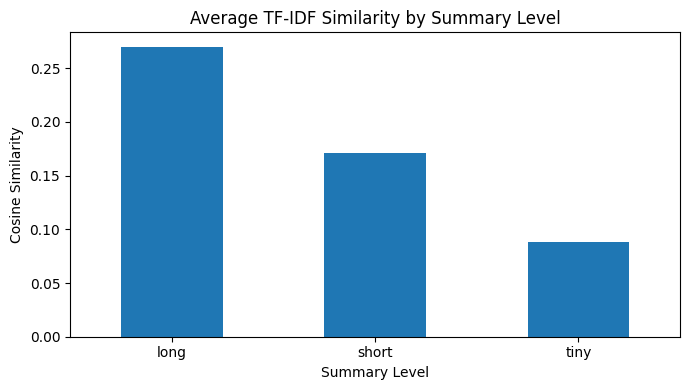

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def tfidf_pair_similarity(text_a, text_b):
    if pd.isna(text_a) or pd.isna(text_b):
        return np.nan

    text_a = str(text_a).strip()
    text_b = str(text_b).strip()

    if text_a == "" or text_b == "":
        return np.nan

    vectorizer = TfidfVectorizer(stop_words="english")
    matrix = vectorizer.fit_transform([text_a, text_b])

    return cosine_similarity(matrix[0], matrix[1])[0, 0]


similarity_rows = []

for _, row in generated_df.iterrows():
    for level, gen_col, ref_col in summary_pairs:
        similarity_rows.append({
            "case_id": row["case_id"],
            "case_type": row["case_type"],
            "summary_level": level,
            "tfidf_cosine_similarity": tfidf_pair_similarity(row[gen_col], row[ref_col])
        })

similarity_df = pd.DataFrame(similarity_rows)

print("TF-IDF cosine similarity by case and summary level:")
display(similarity_df)

similarity_summary = (
    similarity_df
    .groupby("summary_level")["tfidf_cosine_similarity"]
    .mean()
    .round(4)
    .to_frame("mean_tfidf_cosine_similarity")
)

print("Average TF-IDF cosine similarity by summary level:")
display(similarity_summary)

similarity_df.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "summarization_tfidf_similarity_by_case.csv",
    index=False
)

similarity_summary.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "summarization_tfidf_similarity_summary.csv"
)

ax = similarity_summary.plot(kind="bar", figsize=(7, 4), legend=False)
ax.set_title("Average TF-IDF Similarity by Summary Level")
ax.set_xlabel("Summary Level")
ax.set_ylabel("Cosine Similarity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "tfidf_similarity_by_summary_level.png", dpi=150)
plt.show()

### TF-IDF similarity finding

TF-IDF cosine similarity is highest for long summaries and lowest for tiny summaries. This is expected because longer summaries contain more topical words, making lexical overlap easier to capture. Tiny summaries are much shorter, so small wording differences can produce low similarity even when the generated summary is broadly about the correct topic.

Together with ROUGE, this suggests that automatic metrics are useful but incomplete. They should be interpreted alongside qualitative review, especially for legal summarization where factual framing matters.

In [21]:
# Merge useful metric summaries into one compact table for presentation.
summary_metrics = rouge_summary.copy()
summary_metrics["mean_tfidf_cosine_similarity"] = similarity_summary["mean_tfidf_cosine_similarity"]

display(summary_metrics)

summary_metrics.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "summarization_metrics_summary.csv"
)

# Save final generated summaries with length features.
final_summary_path = PROJECT_ROOT / "outputs" / "samples" / "sample_summaries_with_metrics.csv"

generated_df.to_csv(final_summary_path, index=False)

print("Saved final generated summary sample:")
print(final_summary_path)

print("\nFiles created/updated:")
for path in [
    PROJECT_ROOT / "outputs" / "samples" / "sample_summaries.csv",
    PROJECT_ROOT / "outputs" / "samples" / "sample_summaries_with_metrics.csv",
    PROJECT_ROOT / "outputs" / "tables" / "summarization_length_comparison.csv",
    PROJECT_ROOT / "outputs" / "tables" / "summarization_qualitative_comparison.csv",
    PROJECT_ROOT / "outputs" / "tables" / "summarization_rouge_by_case.csv",
    PROJECT_ROOT / "outputs" / "tables" / "summarization_rouge_summary.csv",
    PROJECT_ROOT / "outputs" / "tables" / "summarization_tfidf_similarity_by_case.csv",
    PROJECT_ROOT / "outputs" / "tables" / "summarization_tfidf_similarity_summary.csv",
    PROJECT_ROOT / "outputs" / "tables" / "summarization_metrics_summary.csv",
]:
    print(path.name, "| exists:", path.exists())

,rouge1_f,rouge2_f,rougeL_f,mean_tfidf_cosine_similarity
summary_level,,,,
long,0.2472,0.0966,0.1421,0.2699
short,0.3302,0.0792,0.1922,0.1711
tiny,0.2146,0.0517,0.1727,0.0885


Saved final generated summary sample:
/content/gdrive/MyDrive/Colab Notebooks/Ronny/Zikun New/outputs/samples/sample_summaries_with_metrics.csv

Files created/updated:
sample_summaries.csv | exists: True
sample_summaries_with_metrics.csv | exists: True
summarization_length_comparison.csv | exists: True
summarization_qualitative_comparison.csv | exists: True
summarization_rouge_by_case.csv | exists: True
summarization_rouge_summary.csv | exists: True
summarization_tfidf_similarity_by_case.csv | exists: True
summarization_tfidf_similarity_summary.csv | exists: True
summarization_metrics_summary.csv | exists: True


## Notebook 3 Summary: Summarization Findings

This notebook tested transformer-based summarization on a small representative sample of 5 Multi-LexSum cases. The model used was `sshleifer/distilbart-cnn-12-6`, selected because it provides a practical balance between runtime efficiency and summarization quality.

### Runtime setup

The notebook was run on an A100 GPU. Summarizing 5 cases took about 1 minute and 20 seconds, which confirms that the small-sample strategy is practical for a final project demo.

### Chunking strategy

Because the legal source documents are much longer than the model context window, direct summarization is not feasible. The notebook used a hierarchical summarization strategy:

1. Split each legal case into token chunks.
2. Summarize each chunk.
3. Combine the chunk summaries.
4. Summarize again into long, short, and tiny outputs.

For runtime control, the demo used only the first several chunks of each case. This makes the notebook reproducible, but it also means that later parts of a case may be omitted.

### Length findings

The generated summaries follow the intended granularity order:

- Long summaries are longer than short summaries.
- Short summaries are longer than tiny summaries.

However, the generated long summaries are much shorter than the expert-written long references. This is expected because the demo uses a lightweight model and limited chunks. The generated short summaries are closer in length to the expert short summaries.

### ROUGE findings

Average ROUGE F1 scores:

| Summary Level | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---:|---:|---:|
| Long | 0.2472 | 0.0966 | 0.1421 |
| Short | 0.3302 | 0.0792 | 0.1922 |
| Tiny | 0.2146 | 0.0517 | 0.1727 |

Short summaries achieved the strongest ROUGE-1 and ROUGE-L scores, likely because their length and level of detail were closest to the generated summaries.

### TF-IDF similarity findings

Average TF-IDF cosine similarity:

| Summary Level | Mean TF-IDF Similarity |
|---|---:|
| Long | 0.2699 |
| Short | 0.1711 |
| Tiny | 0.0885 |

Long summaries had the highest TF-IDF similarity because they contain more topical words and therefore more opportunities for lexical overlap. Tiny summaries had the lowest similarity because they are short and sensitive to wording differences.

### Qualitative findings

The generated summaries are useful as drafts, but they are not always fully aligned with the expert references. Some cases capture the main issue well, such as indigent defense retaliation, child welfare sibling visitation, and prisoners’ religious liberty.

However, some outputs over-focus on early source-document context or contain factual wording issues. For example, the policing case focused heavily on George Floyd and Derek Chauvin, while the reference emphasized police force against peaceful protesters. The immigration/FOIA case also showed wording problems around ICE and the plaintiff.

### Limitation

This summarization pipeline should be treated as an educational NLP demonstration, not a legal summarization system. For legal documents, human review is necessary because factual accuracy, procedural posture, and omitted context matter.